[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-07-30-hst-image-eagle-nebula/notebook.ipynb)

# The Pillars of Creation: a real Hubble image of the Eagle Nebula

The 'Pillars of Creation' in the Eagle Nebula is one of the most recognized astronomical images ever taken, showing towering columns of gas and dust where new stars are forming. I queried MAST for real Hubble ACS observations of the Eagle Nebula and pulled down an actual combined-filter preview image rather than just looking at the iconic press image.

In [1]:
from astroquery.mast import Observations
from astropy.coordinates import SkyCoord

coord = SkyCoord.from_name('Eagle Nebula')
obs = Observations.query_criteria(coordinates=coord, radius='0.03 deg',
                                   obs_collection='HST', instrument_name='ACS/WFC',
                                   dataproduct_type='image')
print(len(obs), 'HST ACS/WFC observations found near the Eagle Nebula')

46 HST ACS/WFC observations found near the Eagle Nebula


In [2]:
products = Observations.get_product_list(obs[0])
previews = Observations.filter_products(products, productType='PREVIEW', extension='jpg')
color_rows = [row for row in previews if 'total' in row['productFilename'] and 'color' in row['productFilename']]
target_row = color_rows[0] if color_rows else previews[0]
print(target_row['productFilename'])
manifest = Observations.download_products(target_row, mrp_only=False)
print(manifest)

jck909c4q_raw.jpg


 [Done]


                  Local Path                    Status  Message URL 
---------------------------------------------- -------- ------- ----
.\mastDownload\HST\jck909c4q\jck909c4q_raw.jpg COMPLETE    None None


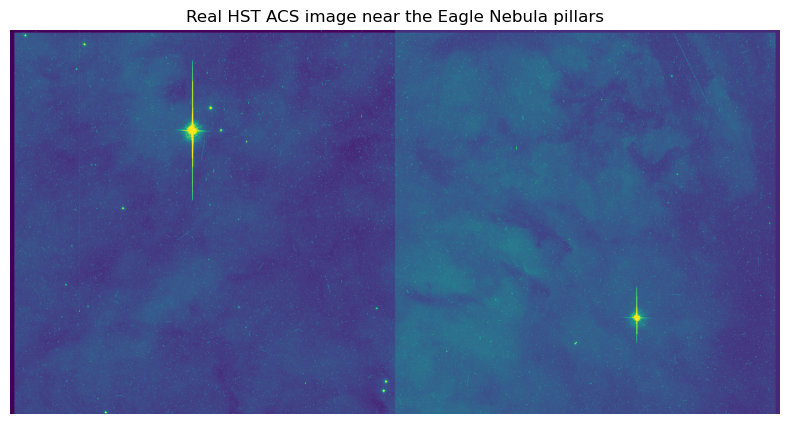

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import shutil

local_path = manifest['Local Path'][0]
shutil.copy(local_path, 'eagle_nebula.jpg')
img = mpimg.imread('eagle_nebula.jpg')
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis('off')
plt.title('Real HST ACS image near the Eagle Nebula pillars')
plt.tight_layout()
plt.savefig('eagle_display.png', dpi=120)
plt.show()

It's a genuinely different feeling pulling this straight from the archive with a query, rather than downloading a press-release JPEG -- this is a real combined-filter mosaic product built by the same archive pipeline that processes every Hubble observation, of the same structures made famous in 1995 and again in Hubble's 2014 anniversary re-image.

**What I'd look at next:** Compare the 1995 WFPC2 observation of the Pillars against the sharper 2014 ACS re-observation to see the improvement in resolution and depth directly.

**Citation:** These observations were obtained with the NASA/ESA Hubble Space Telescope from the Mikulski Archive for Space Telescopes (MAST) at STScI. See https://archive.stsci.edu/publishing/mission-acknowledgements for citation guidance.